In [1]:
import os
import re
import concurrent.futures as conc
from pathlib import Path

import pandas as pd
import numpy as np

import vtk
from vtk.util.numpy_support import vtk_to_numpy

from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances, pairwise_distances_chunked
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import ipywidgets as ipyw
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib widget

class ImageSliceViewer3D:
    
    def __init__(self, volume, figsize=(8,8), cmap='plasma', show=False, v=None):
        self.volume = volume
        self.figsize = figsize
        self.cmap = cmap
        if not v:
            self.v = [np.min(volume), np.max(volume)]
        else:
            self.v = v
        
        # Call to select slice plane
        ipyw.interact(self.view_selection, view=ipyw.RadioButtons(
            options=['x-y','y-z', 'z-x'], value='x-y', 
            description='Slice plane selection:', disabled=(not show),
            style={'description_width': 'initial'}))
    
    def view_selection(self, view):
        # Transpose the volume to orient according to the slice plane selection
        orient = {"y-z":[1,2,0], "z-x":[2,0,1], "x-y": [0,1,2]}
        self.vol = np.transpose(self.volume, orient[view])
        maxZ = self.vol.shape[2] - 1
        
        # Call to view a slice within the selected slice plane
        ipyw.interact(self.plot_slice, 
            z=ipyw.IntSlider(min=0, max=maxZ, step=1, continuous_update=True, 
            description='Image Slice:'))
        
    def plot_slice(self, z):
        # Plot slice for the given plane and slice
        self.fig = plt.figure(figsize=self.figsize)
        plt.imshow(self.vol[:,:,z], cmap=plt.get_cmap(self.cmap), 
            vmin=self.v[0], vmax=self.v[1])

In [4]:
class Frame:
    def __init__(self, path, dim=(100, 100, 100)):
        reader = vtk.vtkStructuredPointsReader()
        reader.SetFileName(path)
        reader.ReadAllScalarsOn()
        reader.Update()
        out = reader.GetOutput()
        d = out.GetPointData()
        names = [d.GetArrayName(i) for i in range(3)] 
        fields =  {n: vtk_to_numpy(d.GetArray(n)) for n in names} 
        types, cells = fields['CellType'] , fields['CellId']
        
        self.types = types.reshape(*dim)
        self.cells = cells.reshape(*dim)
        self.mcs = int(re.search('Step_(\d+).vtk', path).groups()[0])
        self.dim = dim
        
    def as_points(self):
        # returns the cells as 3D points
        dim = np.array(self.dim)
        points = np.vstack(np.unravel_index(np.arange(dim.prod()), dim))
        return points.T
        
    def show(self):
        # shows this frame in an ipyvolume frame
        points = self.as_points()
        for t in np.unique(self.types):
            fig = ip
            ipv.quickscatter(celldf.x.values, celldf.y.values, celldf.z.values, size=1, color=celldf.type, marker="box")
            
    def cluster(self, eps=2):
        points = self.as_points()
        types = self.types.flatten()
        cells = points[types != 0]
        celltypes = types[types != 0]
        db = DBSCAN(eps=eps, min_samples=10).fit(cells)
        core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
        core_samples_mask[db.core_sample_indices_] = True
        labels = db.labels_
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)

        unique_labels = set(labels)
        colors = [plt.cm.Spectral(each)
                  for each in np.linspace(0, 1, len(unique_labels))]

        cluster = None
        for k, col in zip(unique_labels, colors):
            if k == -1:
                # Black used for noise.
                col = [0, 0, 0, 1]

            class_member_mask = (labels == k)

            xyz = cells[class_member_mask & core_samples_mask]
            if cluster is None or len(cluster) < len(xyz):
                cluster = xyz

        return np.array(cluster)

    def variance_ratio(self, plot=False):
        points = self.cluster()
        vol = points.shape[0]
        #max_d = distance_matrix(points, points).max()
        com = np.mean(points, axis=0)
        model = PCA(n_components=2)
        res = model.fit(points)
        if plot:
            fig = plt.figure()
            ax = fig.add_subplot(projection='3d')
            ax.scatter3D(points[:, 0], points[:, 1], points[:, 2], alpha=0.05)
            comp = (res.components_.T * res.explained_variance_).T
            ax.quiver3D(com[0], com[1], com[2], comp[0, 0], comp[0, 1], comp[0, 2], color='red')
            ax.quiver3D(com[0], com[1], com[2], comp[1, 0], comp[1, 1], comp[1, 2], color='green')
        return vol*(res.explained_variance_ratio_[0]/res.explained_variance_ratio_[1])
            
        
class Movie:
    def __init__(self, path):
        self.path = os.path.join(path, 'LatticeData')
        files = os.listdir(self.path)
        #print(f'reading {len(files)} frames from {self.path}')
        
        with conc.ProcessPoolExecutor() as ex:
            frames = ex.map(Frame, [os.path.join(self.path, file) for file in files if file.endswith('.vtk')])
            self.frames = sorted(frames, key=lambda x: x.mcs)

        self.t_max = len(self.frames)-1
    
    def frame_by_mcs(self, t):
        for frame in self.frames:
            if frame.mcs == t:
                return frame
        return None
    def frame_by_idx(self, i):
        if i >= 0 and i < len(self.frames):
            return self.frames[i] 
        return None
    
    def frames(self):
        return self.frames
    
    def variance_ratios(self):
        return [f.variance_ratio() for f in self.frames]

# 2L slices

In [4]:
%matplotlib inline
for exp in Path('2L_try3').iterdir():
    print(exp.name)
    for sim in exp.iterdir():
        if sim.is_dir():
            print(sim.name)
            os.makedirs(sim/'slices', exist_ok=True)
            try:
                f = Frame(str(sim/'LatticeData'/'Step_24000.vtk'))

                for z in range(40, 61):
                    plt.figure()
                    plt.imshow(f.types[:,:,z], cmap=ListedColormap(['white', 'yellow', 'green', 'blue', 'red']), 
            vmin=0, vmax=4)
                    plt.savefig(sim/'slices'/f'{z}.png')
                    plt.close()
            except Exception as e:
                print(e)
                print(sim)

2L_ncad_pcad_plus5_aa
sim_005
sim_002
sim_003
sim_004
sim_017
sim_010
sim_019
sim_018
sim_011
sim_016
sim_008
sim_001
sim_006
sim_007
sim_000
sim_009
sim_013
sim_014
sim_015
sim_012
2L_ncad_pcad_minus5_aa
sim_005
sim_002
sim_003
sim_004
sim_017
sim_010
sim_019
sim_018
sim_011
sim_016
sim_008
sim_001
sim_006
sim_007
sim_000
sim_009
sim_013
sim_014
sim_015
sim_012


# homogeneity index

In [5]:
import sqlalchemy

In [6]:
%matplotlib inline

# homogeneity index
for exp in Path('2L_try3').iterdir():
    print(exp.name)
    dfs = []
    for sim in exp.iterdir():
        if sim.is_dir():
            try:
                engine = sqlalchemy.create_engine('sqlite:///'+str(sim/'results.db'))
                df = pd.read_sql_table('psi', con=engine)
                dfs.append(df)
            except Exception as e:
                print(sim)
    psidf = pd.concat(dfs)
    plt.figure()
    sns.lineplot(data=psidf[psidf.t.gt(0)], x='t', y='value', hue='type')
    plt.savefig(exp/'psi.png', dpi=300)
    plt.close()

2L_ncad_pcad_plus5_aa
2L_ncad_pcad_minus5_aa


# points test

In [49]:
%matplotlib inline
import sqlalchemy
# homogeneity index
dfs = []
for sim in Path('points/points_test').iterdir():
    if sim.is_dir():
        try:
            engine = sqlalchemy.create_engine('sqlite:///'+str(sim/'results.db'))
            df = pd.read_sql_table('points', con=engine)
            dfs.append(df)
        except Exception as e:
            print(sim, e)

In [50]:
pointsdf = pd.concat(dfs)

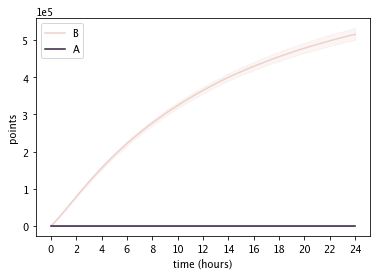

In [59]:
plt.figure()
sns.lineplot(data=pointsdf[pointsdf.type.isin([1, 3]) & pointsdf.t.le(24000)], x='t', y='value', hue='type')
L = plt.legend()
L.get_texts()[0].set_text('B')
L.get_texts()[1].set_text('A')
plt.xticks(np.arange(0, 25000, 2000), np.arange(0, 25, 2))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('time (hours)')
plt.ylabel('points')
plt.savefig(Path('points/points_test')/'points.png', dpi=300)

# elongation grid

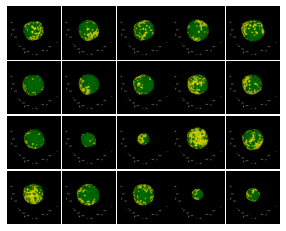

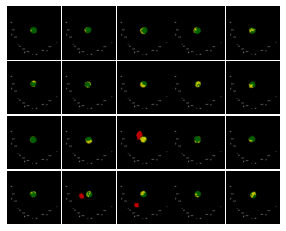

In [5]:
%matplotlib inline
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

for exp in ['elongation_impl2_try10', 'elongation_impl2_try11']:
    imgs = []
    for sim in Path('elongation/'+exp).iterdir():
        if not sim.is_dir() or 'ipynb' in sim.name:
            continue
        sim_imgs = sorted(list((sim/'screenshots').iterdir()))
        imgs.append(mpimg.imread(sim_imgs[-1]))
    fig = plt.figure()

    grid = ImageGrid(fig, 111, nrows_ncols=(4, 5))
    for im, ax in zip(imgs, grid):
        ax.imshow(im)
        ax.axis('off')
    plt.savefig(Path('elongation/'+exp)/'grid.png', dpi=300)

# elongation fitness

In [7]:
# try max_d and the other ones
def fitness(points):
    '''
    fitness of a single frame, where points is an (n x 3) array of pixels
    '''
    """
    vol = points.shape[0]
    dists = pairwise_distances_chunked(points, n_jobs=-1)
    d_max = -1
    for d in dists:
            chunk_max = d.max()
            if chunk_max > d_max:
                d_max = chunk_max
    com = np.mean(points, axis=0)
    """
    model = PCA(n_components=2)
    res = model.fit(points)
    return res.explained_variance_ratio_[0]/res.explained_variance_ratio_[1]

In [8]:
exps = ['elongation_impl2_try10', 'elongation_impl2_try9', 'elongation_impl2_try6']
fitnesses = []
for e in exps:
    exp = Path('elongation/'+e)
    for sim in exp.iterdir():
        if not sim.is_dir() or 'ipynb' in sim.name:
            continue
        print(sim)
        try:
            frame = Frame(str(sim/'LatticeData'/'Step_100000.vtk'))
            fit = fitness(frame.cluster())
            fitnesses.append([exp.name, fit])
        except Exception as e:
            print(sim, e)

elongation/elongation_impl2_try10/sim_005
elongation/elongation_impl2_try10/sim_002
elongation/elongation_impl2_try10/sim_003
elongation/elongation_impl2_try10/sim_004
elongation/elongation_impl2_try10/sim_017
elongation/elongation_impl2_try10/sim_010
elongation/elongation_impl2_try10/sim_019
elongation/elongation_impl2_try10/sim_018
elongation/elongation_impl2_try10/sim_011
elongation/elongation_impl2_try10/sim_016
elongation/elongation_impl2_try10/sim_008
elongation/elongation_impl2_try10/sim_001
elongation/elongation_impl2_try10/sim_001 'NoneType' object has no attribute 'GetDataType'
elongation/elongation_impl2_try10/sim_006
elongation/elongation_impl2_try10/sim_006 'NoneType' object has no attribute 'GetDataType'
elongation/elongation_impl2_try10/sim_007
elongation/elongation_impl2_try10/sim_000
elongation/elongation_impl2_try10/sim_009
elongation/elongation_impl2_try10/sim_013
elongation/elongation_impl2_try10/sim_014
elongation/elongation_impl2_try10/sim_015
elongation/elongatio

In [13]:
fdf = pd.DataFrame(fitnesses, columns=['experiment', 'variance ratio'])

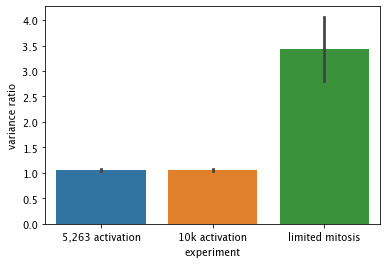

In [14]:
plt.figure()
sns.barplot(x='experiment', y='variance ratio', data=fdf)
plt.xticks([0, 1, 2], ['5,263 activation', '10k activation', 'limited mitosis'])
plt.savefig('fitness_breakdown_fixed.png', dpi=300)

In [9]:
# try 10: no changes
# try 9: 10k activation
# try 6: limited mitosis

In [101]:
fdf_rows = []
for f in fitnesses:
    fdf_rows.extend([[f[0], f[1], 'd_max/vol^(1/3)'], [f[0], f[2], 'PCA ratios'], [f[0], f[1]*f[2], 'combined']])

In [102]:
fdf = pd.DataFrame(fdf_rows, columns=['experiment', 'value', 'term'])

In [112]:
fdf.to_json('fdf_2.json')

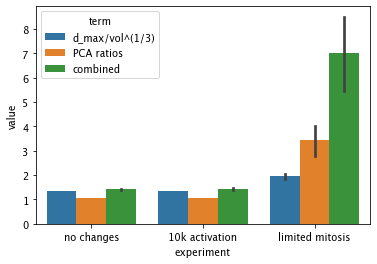

In [111]:
plt.figure()
sns.barplot(x='experiment', y='value', data=fdf, hue='term')
plt.xticks([0, 1, 2], ['no changes', '10k activation', 'limited mitosis'])
plt.savefig('fitness_breakdown.png', dpi=300)

In [46]:
plt.figure()
sns.barplot(x='exp', y='fitness', data=fdf)
plt.xticks([0, 1, 2], ['no changes', 'limited mitosis', '10k activation'])
plt.savefig('fitness', dpi=300)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [29]:
fdf.to_json('fdf.json')